In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


In [2]:
np.random.seed(0)

X = np.linspace(1, 50, 30).reshape(-1, 1)
y = 0.05 * X**2 + 2 * X + 10 + np.random.randn(30, 1) * 20
y = y.ravel()


In [3]:
X

array([[ 1.        ],
       [ 2.68965517],
       [ 4.37931034],
       [ 6.06896552],
       [ 7.75862069],
       [ 9.44827586],
       [11.13793103],
       [12.82758621],
       [14.51724138],
       [16.20689655],
       [17.89655172],
       [19.5862069 ],
       [21.27586207],
       [22.96551724],
       [24.65517241],
       [26.34482759],
       [28.03448276],
       [29.72413793],
       [31.4137931 ],
       [33.10344828],
       [34.79310345],
       [36.48275862],
       [38.17241379],
       [39.86206897],
       [41.55172414],
       [43.24137931],
       [44.93103448],
       [46.62068966],
       [48.31034483],
       [50.        ]])

In [4]:
y

array([ 47.33104692,  23.74416676,  39.29229833,  68.79741214,
        65.87821093,  13.81448996,  57.48030581,  40.85537664,
        47.50762059,  63.75893793,  64.68830305,  97.43885896,
        90.40559398,  84.73528392,  98.58148582, 104.06563875,
       135.24715816, 109.52132937, 128.4302601 , 113.91689615,
        89.05441296, 162.58747298, 176.4902103 , 154.33006463,
       224.8258297 , 160.88628936, 201.7171323 , 208.17213751,
       253.97074481, 264.3871754 ])

In [5]:
df = pd.DataFrame({
    "feature1": X.ravel(),
    "target": y
})


In [6]:
X = df[['feature1']]
y = df['target']

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [8]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


In [9]:
model = LinearRegression()
model.fit(X_train_poly, Y_train)
model.predict([[5.67,5,5]])

array([42.26408385])

In [10]:
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
x_line_poly = poly.transform(x_line)
y_line = model.predict(x_line_poly)


C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


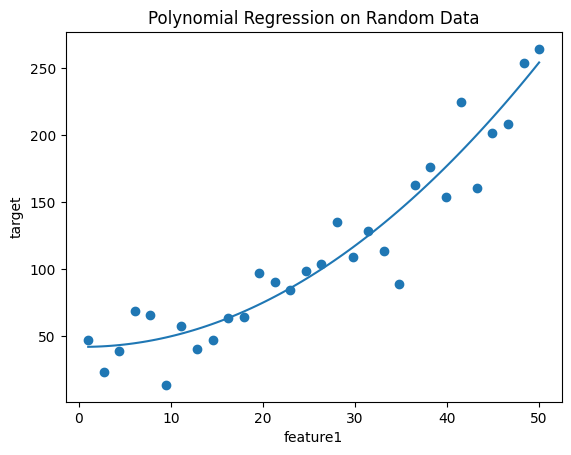

In [11]:
plt.scatter(X, y)
plt.plot(x_line, y_line)
plt.xlabel("feature1")
plt.ylabel("target")
plt.title("Polynomial Regression on Random Data")
plt.show()


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [22]:
np.random.seed(0)

X1 = np.linspace(1, 50, 30)
X2 = np.linspace(10, 100, 30)

y = 0.03 * X1**2 + 0.5 * X2 + 5 + np.random.randn(30) * 10
print(X1)
print(X2)
print(y)

[ 1.          2.68965517  4.37931034  6.06896552  7.75862069  9.44827586
 11.13793103 12.82758621 14.51724138 16.20689655 17.89655172 19.5862069
 21.27586207 22.96551724 24.65517241 26.34482759 28.03448276 29.72413793
 31.4137931  33.10344828 34.79310345 36.48275862 38.17241379 39.86206897
 41.55172414 43.24137931 44.93103448 46.62068966 48.31034483 50.        ]
[ 10.          13.10344828  16.20689655  19.31034483  22.4137931
  25.51724138  28.62068966  31.72413793  34.82758621  37.93103448
  41.03448276  44.13793103  47.24137931  50.34482759  53.44827586
  56.55172414  59.65517241  62.75862069  65.86206897  68.96551724
  72.06896552  75.17241379  78.27586207  81.37931034  84.48275862
  87.5862069   90.68965517  93.79310345  96.89655172 100.        ]
[ 27.67052346  15.77032357  23.46617889  38.16907468  36.6883623
  10.66393939  32.53283423  24.28490592  27.7041135   35.95140714
  36.566274    53.1202856   49.81093611  47.21161342  54.39909606
  57.43410356  73.34634364  60.83345898  7

In [23]:
df = pd.DataFrame({
    "feature1": X1,
    "feature2": X2,
    "target": y
})
df

,feature1,feature2,target
0,1.000000,10.000000,27.670523
1,2.689655,13.103448,15.770324
2,4.379310,16.206897,23.466179
3,6.068966,19.310345,38.169075
4,7.758621,22.413793,36.688362
5,9.448276,25.517241,10.663939
6,11.137931,28.620690,32.532834
7,12.827586,31.724138,24.284906
8,14.517241,34.827586,27.704114
9,16.206897,37.931034,35.951407


In [15]:
X = df[['feature1', 'feature2']]
y = df['target']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [17]:
model = LinearRegression()
model.fit(X_train_poly, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
y_pred = model.predict(X_test_poly)

In [19]:
r2 = r2_score(Y_test, y_pred)
r2

0.9517221663057424

In [29]:
x_line = np.linspace([X.min(), X.max()],[y.min(),y.max()],  100)
x_line_poly = poly.transform(x_line)
y_line = model.predict(x_line_poly)
plt.scatter(X, y)
plt.plot(x_line, y_line)
plt.xlabel("features")
plt.ylabel("target")
plt.title("Polynomial Regression on Random Data")
plt.show()

C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


ValueError: Found array with dim 3, while dim <= 2 is required by PolynomialFeatures.

C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


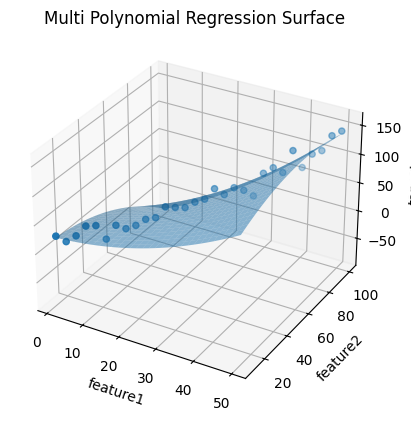

In [20]:
f1 = np.linspace(X['feature1'].min(), X['feature1'].max(), 30)
f2 = np.linspace(X['feature2'].min(), X['feature2'].max(), 30)
F1, F2 = np.meshgrid(f1, f2)

grid = np.c_[F1.ravel(), F2.ravel()]
grid_poly = poly.transform(grid)
Z = model.predict(grid_poly).reshape(F1.shape)

# Plot
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(X['feature1'], X['feature2'], y)
ax.plot_surface(F1, F2, Z, alpha=0.5)

ax.set_xlabel("feature1")
ax.set_ylabel("feature2")
ax.set_zlabel("target")
ax.set_title("Multi Polynomial Regression Surface")

plt.show()

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [12]:
df = pd.read_csv("iceream.csv")
print(df.head())

   Temperature (°C)  Ice Cream Sales (units)
0         -4.662263                41.842986
1         -4.316559                34.661120
2         -4.213985                39.383001
3         -3.949661                37.539845
4         -3.578554                32.284531


In [13]:
x = df["Temperature (°C)"]
y = df["Ice Cream Sales (units)"]
x

0    -4.662263
1    -4.316559
2    -4.213985
3    -3.949661
4    -3.578554
5    -3.455712
6    -3.108440
7    -3.081303
8    -2.672461
9    -2.652287
10   -2.651498
11   -2.288264
12   -2.111870
13   -1.818938
14   -1.660348
15   -1.326379
16   -1.173123
17   -0.773330
18   -0.673753
19   -0.149635
20   -0.036156
21   -0.033895
22    0.008608
23    0.149245
24    0.688781
25    0.693599
26    0.874905
27    1.024181
28    1.240712
29    1.359813
30    1.740000
31    1.850552
32    1.999310
33    2.075101
34    2.318591
35    2.471946
36    2.784836
37    2.831760
38    2.959932
39    3.020874
40    3.211366
41    3.270044
42    3.316073
43    3.335932
44    3.610778
45    3.704057
46    4.130868
47    4.133534
48    4.899032
Name: Temperature (°C), dtype: float64

In [18]:
d = pd.DataFrame(df)
print(d)

    Temperature (°C)  Ice Cream Sales (units)
0          -4.662263                41.842986
1          -4.316559                34.661120
2          -4.213985                39.383001
3          -3.949661                37.539845
4          -3.578554                32.284531
5          -3.455712                30.001138
6          -3.108440                22.635401
7          -3.081303                25.365022
8          -2.672461                19.226970
9          -2.652287                20.279679
10         -2.651498                13.275828
11         -2.288264                18.123991
12         -2.111870                11.218294
13         -1.818938                10.012868
14         -1.660348                12.615181
15         -1.326379                10.957731
16         -1.173123                 6.689123
17         -0.773330                 9.392969
18         -0.673753                 5.210163
19         -0.149635                 4.673643
20         -0.036156              

In [15]:
X_train, X_test, Y_train, Y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [16]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.